# Validation of L1 pipeline performance

We here test the L1 pipeline data products for the P1 and P5 sample. The production of the following data was done using the corresponding input catalogues and the PLATOnium executions:

- platonium.py L1-pipeline 500 1 1 23 --seed 1234 --sample P1
- platonium.py L1-pipeline 500 1 1 23 --seed 1234 --sample P5

This, we test with star ID 500, N-CAM 1.1 and Q23. We here secure that the seeds are fixed in the random number generator, so we can reproduce the results.

In [48]:
import os
import sys
import glob
import numpy as np
import pandas as pd
from colorama import Back, Fore, Style
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter
import statsmodels.api as sm
from statsmodels.graphics.gofplots import qqplot

from platosim.simfile import SimFile
from platosim.plot import plotPhotometry
from platosim.utilities import errorcode, normalize

import warnings
warnings.simplefilter("ignore")

# Constants
ppmh = 144   # For a cadence of 25s
model = 'y ~ x'
ms, aa = 3, 0.1

%matplotlib notebook 

# Directory tree to all files
datadir = '/lhome/nicholas/Nextcloud/tests/validation_L1-pipeline/P1/'

In [50]:
plt.rc('font',   size=12)          # controls default text sizes
plt.rc('axes',   titlesize=12)     # fontsize of the axes title
plt.rc('axes',   labelsize=12)     # fontsize of the x and y labels
plt.rc('xtick',  labelsize=12)     # fontsize of the tick labels
plt.rc('ytick',  labelsize=12)     # fontsize of the tick labels
plt.rc('legend', fontsize=12)      # legend fontsize
plt.rc('figure', titlesize=13)     # fontsize of the figure title

In [49]:
def sortlc(data, flux_err=False):
    
    # Convert to days
    data['time'] = data['time']/86400
    
    # Normalize flux and find medina filter
    data['flux']     = normalize(data['flux'])
    data['flux_med'] = median_filter(data['flux'], ppmh) 
    
    # P1 sample has flux errors
    if flux_err: data['flux_err'] = normalize(data['flux_err'])
    
    return data



def colortheme(theme):
    # Select theme and PI color
    if theme == 'r': color = ['tomato', 'red', 'orange']
    if theme == 'g': color = ['limegreen', 'forestgreen', 'yellowgreen']
    if theme == 'b': color = ['royalblue', 'darkcyan', 'dodgerblue']
    if theme == 'm': color = ['deeppink', 'darkviolet', 'm']
    if theme == 'y': color = ['khaki', 'gold', 'orange']
    return color



def plot_modelfit(data, lsFit, model, lsModel='OLS', CI=[0.05], alpha=0.1, theme='b', 
                  x='x', y='y', xlab='x', ylab='y', yerr=False):

    # Select theme and PI color
    color = colortheme(theme)
        
    # Set parameter strings 
    reg, pre = 'x', 'y'
    
    # Select model string using R terminology (Linear model is default)
    string = (r'Adj. R$^{2} \approx$ ' + str(round(lsFit.rsquared_adj,2)) + '\n' +
              r'AIC     $\approx$ '    + str(round(lsFit.aic,1)) + '\n' +
              r'BIC     $\approx$ '    + str(round(lsFit.bic,1)) + '\n' +
              r'Cond.  $\approx$ '     + str(round(lsFit.condition_number, 1)) + '\n')
    
    # Fetch fit coefficients
    theta_val, theta_err = [], []
    for i in range(len(lsFit.params)):
        theta_val, theta_err = round(lsFit.params[i],2), round(lsFit.bse[i],2)
        string += fr'$\theta_{i} \approx {theta_val} \pm {theta_err}$' + '\n'
    
    # Select title and model
    title  = r'Fit model: $y = \epsilon + \theta_0$'
    if model == 'y ~ x': title += fr' + $\theta_1 {x}$'   
    if model == 'y ~ x + z': title += fr' + $\theta_1$ {x} + \theta_2 z$'
    if model == 'y ~ x + I(x**2)': title += fr' + $\theta_1 {x} + \theta_2 {x}^2$'
    if model == 'y ~ x + I(np.sin(x))': title += fr' + $\theta_1 {x} + \theta_2 \sin({x})$'            

    # Predict response variable
    n = 100
    xpredict = np.linspace(data[reg].min(), data[reg].max(), n)
    xpredict = np.linspace(data[reg].min(), data[reg].max(), n)
    
    # Select predictions
    ypredict    = lsFit.predict(exog=dict(x=xpredict))
    predictions = lsFit.get_prediction()
    
    # PLOTTING
    fig, ax = plt.subplots(figsize=(13,8))
    
    # plot data
    if yerr:
        ax.errorbar(data[reg], data[pre], yerr=data[yerr], marker='.', color='grey', ls='', alpha=0.1, zorder=0)
        ax.plot(data[reg], data[pre], 'ko', ms=2, alpha=alpha, label="Data", zorder=1)
    else:
        ax.plot(data[reg], data[pre], 'ko', ms=2, alpha=alpha, label="Data", zorder=1)
    
    # Allow more CI intervals
    for i in range(len(CI)):
        df_predictions = predictions.summary_frame(alpha=CI[i])
        df_predictions.index = data.x.values

        # Plot CI
        if len(data) < 1e3:
            ax.fill_between(df_predictions.index, 
                            df_predictions.mean_ci_lower, 
                            df_predictions.mean_ci_upper, 
                            alpha=0.2, color=CI_color[i+1], zorder=2)
        ax.plot(data[reg], df_predictions.mean_ci_lower, '-', c=color[i+1], lw=2, zorder=2, label=str((1-CI[i])*100)+'% CI')
        ax.plot(data[reg], df_predictions.mean_ci_upper, '-', c=color[i+1], lw=2, zorder=2)
    
    # Plot PI -> only relevant for OLS
    if len(data) < 1e3:
        ax.fill_between(df_predictions.index, 
                        df_predictions.obs_ci_lower, 
                        df_predictions.obs_ci_upper, 
                        alpha=0.2, color=PI_color, zorder=3)
    ax.plot(data[reg], df_predictions.obs_ci_lower, '-', c=color[-1], lw=2, zorder=2, label=str((1-CI[0])*100)+'% PI')
    ax.plot(data[reg], df_predictions.obs_ci_upper, '-', c=color[-1], lw=2, zorder=2)
    
    # Plot best fit and data
    ax.plot(df_predictions['mean'], color=color[0], label='Fit', zorder=3)
        
    # Settings
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.set_title(title,fontsize=15)
    ax.legend(fontsize=13, title='',fancybox=True, framealpha=0.8, loc='upper right')
    ax.set_xlim(data[reg].iloc[0], data[reg].iloc[-1])
    
    # Add fit box
    RMS = round(np.sqrt(np.mean( (data[pre]-df_predictions['mean'])**2 )))
    string += f'RMS = {RMS} ppm'
    props = dict(boxstyle='round', facecolor=color[0], alpha=0.3)
    ax.text(1.02, 0.98, string, transform=ax.transAxes, fontsize=14, 
            verticalalignment='top', bbox=props)            
    plt.show()
    
    
    
    
    
def plot_residuals(data, lsFit, theme='b', reg='x', alpha=0.1, lsModel='OLS'):
    
    # Choose correct residuals
    if lsModel == 'OLS':  resid = lsFit.resid
    else: resid = lsFit.resid_pearson
    
    color = colortheme(theme)
    fig, ax = plt.subplots(1,2, figsize=(16,5))

    # Plot residuals squared vs. observations
    ax[0].plot(data[reg], resid**2, 'ko', ms=2, alpha=alpha, zorder=1)
    ax[0].grid(True,   color='grey',   ls='-',  lw=0.5, zorder=2)
    ax[0].axhline(y=0, color=color[0], ls='--', lw=2.0, zorder=3)
    ax[0].set_xlabel(reg)
    ax[0].set_ylabel(r"Residuals squared, $\varepsilon^2$")
    ax[0].set_xlim(data[reg].iloc[0], data[reg].iloc[-1])
    
    # Plot residuals vs. plot
    ax[1].plot(lsFit.fittedvalues, resid, 'ko', ms=2, alpha=alpha, zorder=1)
    ax[1].grid(True,   color='grey',    ls='-',  lw=0.5, zorder=2)
    ax[1].axhline(y=0, color=color[0],  ls='--', lw=2.0, zorder=3)
    ax[1].set_xlabel("Predicted reponse")
    ax[1].set_ylabel(r"Residuals, $\epsilon$")
    ax[1].set_xlim(np.min(lsFit.fittedvalues), np.max(lsFit.fittedvalues))
    plt.show()
    
    
    
    
def plot_standardized_residuals(data, lsFit, K, reg='x', lsModel='OLS'):
    
    # Choose correct residuals
    if lsModel == 'OLS':  resid = lsFit.resid
    else: resid = lsFit.resid_pearson
    
    N = len(data[reg])
    s2 = np.sum(resid**2) / (N-K)
    standardizedResiduals = resid / np.sqrt(s2)
    
    # Plot standardized residuals (QQ-plot)
    fig, ax = plt.subplots(figsize=(10,6))
    qqplot(standardizedResiduals, line='45', ax=ax)
    plt.show()
    

# On-ground light curves (P1 sample)

In [24]:
star = '000000500'

# Varsource
var = pd.read_csv(datadir + f'varsource_{star}.txt', names=['time', 'dmag'], sep=' ', header=None)
var['time'] = var['time'] / 86400
var['flux'] = (10**(-var['dmag']/2.5) - 1) * 1e6 

# Load L1 pipeline
lc = pd.read_feather(datadir + f'{star}_Ncam1.1_Q23.ftr')
lc1 = sortlc(lc)

<IPython.core.display.Javascript object>


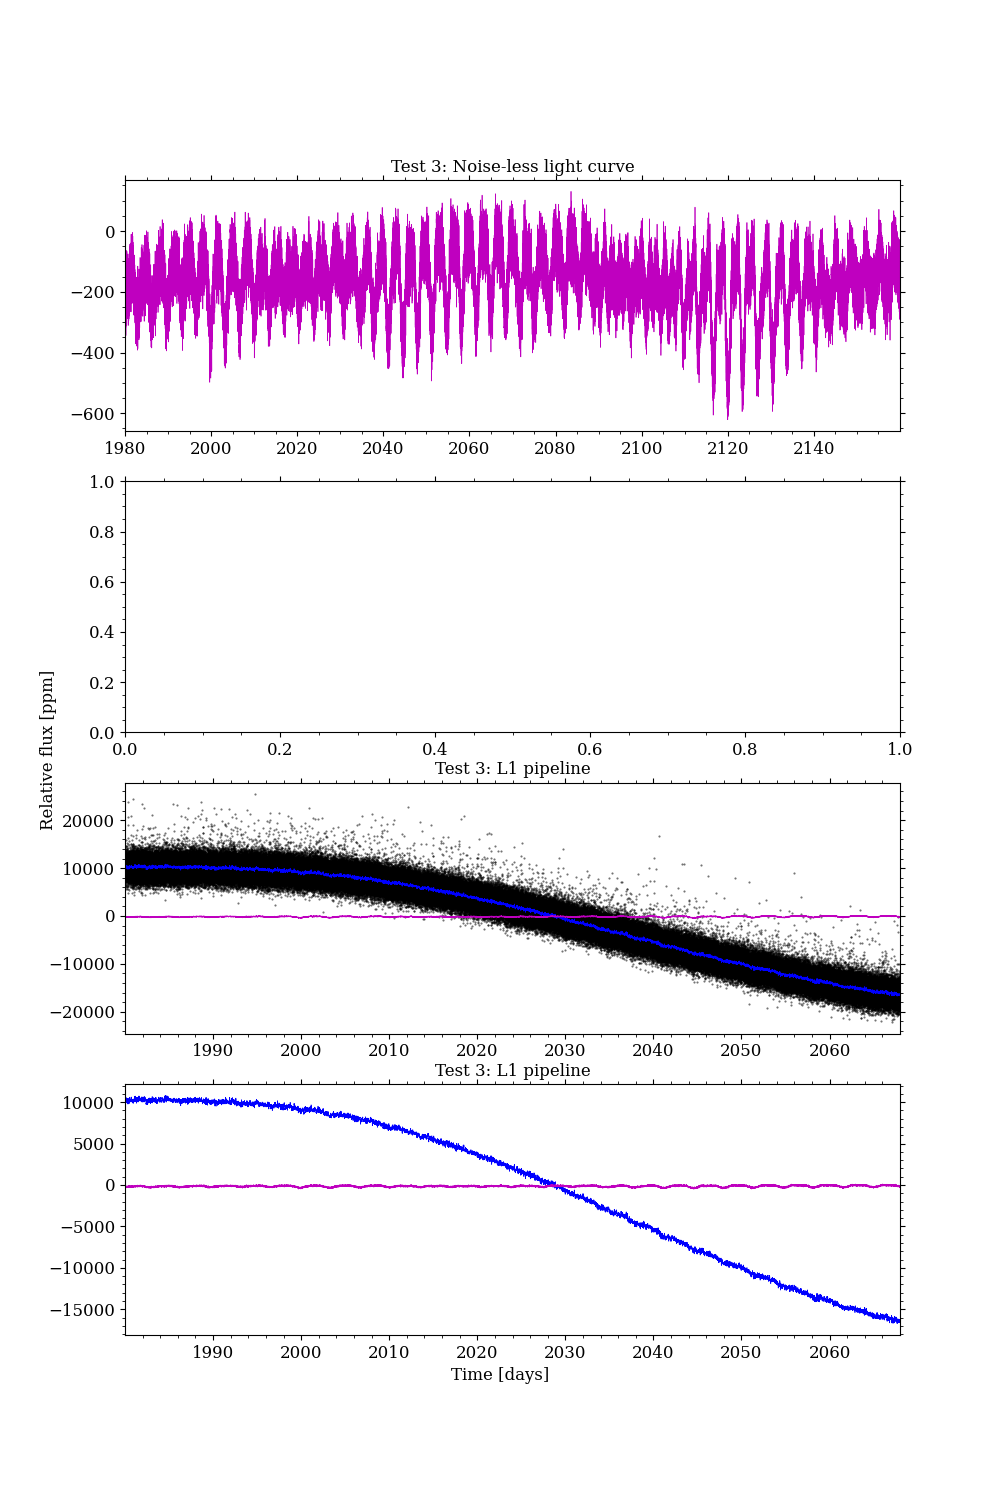

In [26]:
fig, ax = plt.subplots(3, 1, figsize=(10, 15))

# Crop for Q24 only
time = var['time']#.iloc[len(lc1['time']):]
flux = var['flux']#.iloc[len(lc1['time']):]

# Plot input variable source
ax[0].plot(time, flux, 'm-', lw=0.5)
ax[0].set_title('Noise-less light curve')
ax[0].set_xlim(time.iloc[0], time.iloc[-1])

# Plot L1 pipeline ligth curve
ax[1].plot(lc1['time'], lc1['flux'], 'k.', ms=1, alpha=0.6)
ax[1].plot(lc1['time'], lc1['flux_med'], 'b-', lw=0.5)
ax[1].plot(time, flux, 'm-', lw=0.5)
# ax[2].set_ylim(-2e4, 2e4)
ax[1].set_xlim(lc1['time'].iloc[0], lc1['time'].iloc[-1])
ax[1].set_title('L1 pipeline')

# Plot L1 pipeline ligth curve
ax[2].plot(lc1['time'], lc1['flux_med'], 'b-', lw=0.5)
ax[2].plot(time, flux, 'm-', lw=0.5)
ax[2].set_xlim(lc1['time'].iloc[0], lc1['time'].iloc[-1])
ax[2].set_title('Test 3: L1 pipeline')

# Settings
fig.text(0.5, 0.08, 'Time [days]', ha='center')
fig.text(0.04, 0.5, 'Relative flux [ppm]', va='center', rotation='vertical')
plt.show()

In [35]:
star = '500/000000500'

# Varsource
var = pd.read_csv(datadir + f'../varsource.txt', names=['time', 'dmag'], sep=' ', header=None)
var['time'] = var['time'] / 86400
var['flux'] = (10**(-var['dmag']/2.5) - 1) * 1e6 

# Load L1 pipeline
lc = pd.read_feather(datadir + f'{star}_Ncam1.1_Q23.ftr')
lc1 = sortlc(lc)

<IPython.core.display.Javascript object>


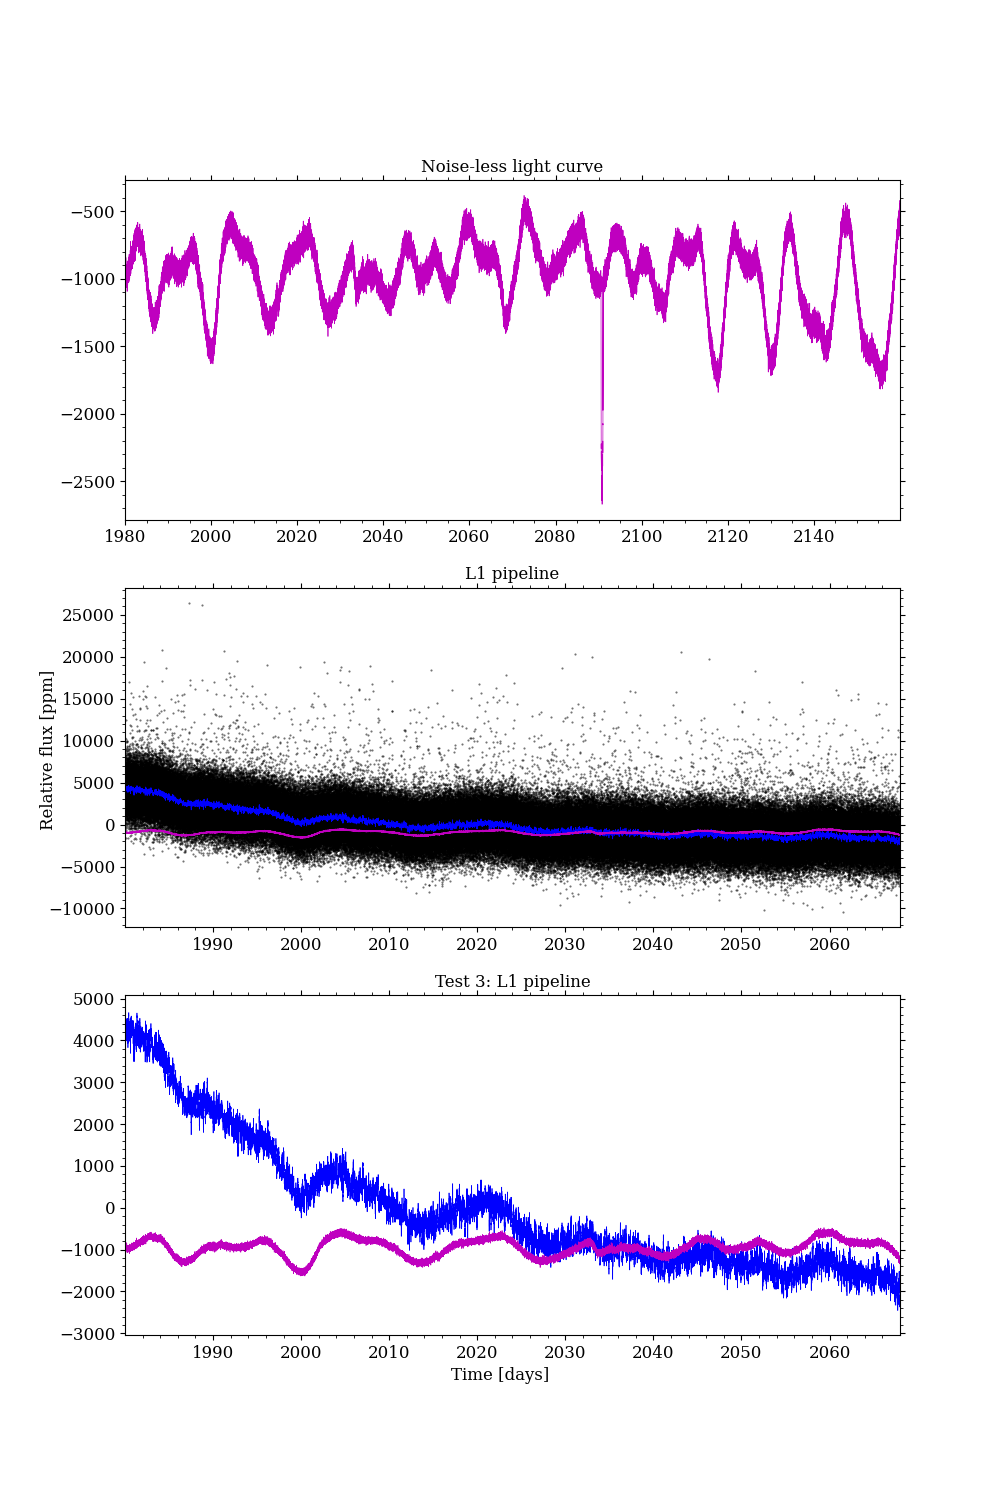

In [36]:
fig, ax = plt.subplots(3, 1, figsize=(10, 15))

# Crop for Q24 only
time = var['time']#.iloc[len(lc1['time']):]
flux = var['flux']#.iloc[len(lc1['time']):]

# Plot input variable source
ax[0].plot(time, flux, 'm-', lw=0.5)
ax[0].set_title('Noise-less light curve')
ax[0].set_xlim(time.iloc[0], time.iloc[-1])

# Plot L1 pipeline ligth curve
ax[1].plot(lc1['time'], lc1['flux'], 'k.', ms=1, alpha=0.6)
ax[1].plot(lc1['time'], lc1['flux_med'], 'b-', lw=0.5)
ax[1].plot(time, flux, 'm-', lw=0.5)
# ax[2].set_ylim(-2e4, 2e4)
ax[1].set_xlim(lc1['time'].iloc[0], lc1['time'].iloc[-1])
ax[1].set_title('L1 pipeline')

# Plot L1 pipeline ligth curve
ax[2].plot(lc1['time'], lc1['flux_med'], 'b-', lw=0.5)
ax[2].plot(time, flux, 'm-', lw=0.5)
ax[2].set_xlim(lc1['time'].iloc[0], lc1['time'].iloc[-1])
ax[2].set_title('Test 3: L1 pipeline')

# Settings
fig.text(0.5, 0.08, 'Time [days]', ha='center')
fig.text(0.04, 0.5, 'Relative flux [ppm]', va='center', rotation='vertical')
plt.show()

In [51]:
star = '000000010'

# Varsource
var = pd.read_csv(datadir + f'{star}/varsource_{star}.txt', names=['time', 'dmag'], sep=' ', header=None)
var['time'] = var['time'] / 86400
var['flux'] = (10**(-var['dmag']/2.5) - 1) * 1e6 

# Load L1 pipeline
lc = pd.read_feather(datadir + f'{star}/{star}_Ncam1.1_Q23.ftr')
lc1 = sortlc(lc)

<IPython.core.display.Javascript object>


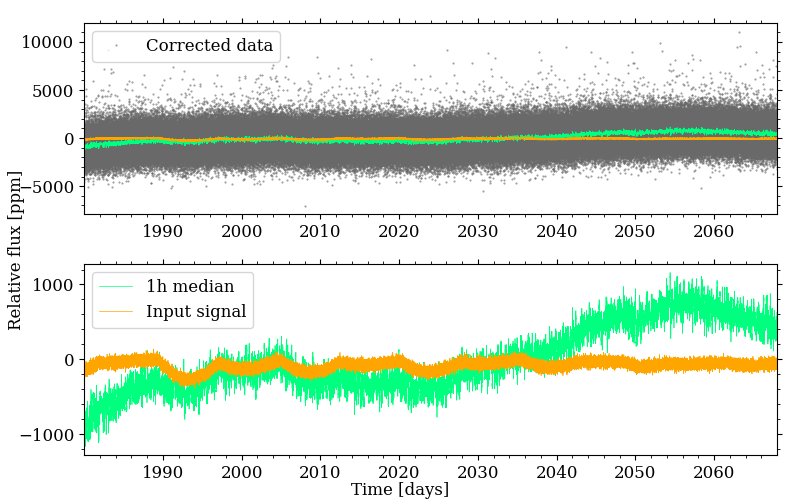

In [57]:
fig, ax = plt.subplots(2, 1, figsize=(8, 5))

# Plot L1 pipeline ligth curve
ax[0].plot(lc1['time'], lc1['flux'], '.', ms=1, c='dimgrey', alpha=0.7, label='Corrected data')
ax[0].plot(lc1['time'], lc1['flux_med'],   '-', c='springgreen', lw=0.5)
ax[0].plot(var['time'], var['flux'],       '-', c='orange', lw=0.5)
ax[0].set_xlim(lc1['time'].iloc[0], lc1['time'].iloc[-1])
ax[0].legend(loc='upper left')

# Plot L1 pipeline ligth curve
ax[1].plot(lc1['time'], lc1['flux_med'], '-', color='springgreen',   lw=0.5, label='1h median')
ax[1].plot(var['time'], var['flux'],     '-', color='orange', lw=0.5, label='Input signal')
ax[1].set_xlim(lc1['time'].iloc[0], lc1['time'].iloc[-1])
ax[1].legend(loc='upper left')

# Settings
fig.text(0.5, 0.01, 'Time [days]', ha='center')
fig.text(0.01, 0.5, 'Relative flux [ppm]', va='center', rotation='vertical')
plt.tight_layout()
plt.show()

plt.savefig('test.pdf')  